In [ ]:
# This code simulates a single neuron of choice
#import brian2
from brian2 import *
import sys
sys.path.append('Neuron and Synapse Models')
from NeuronModels import *
import matplotlib.pyplot as plt

In [ ]:
# Parameters
Vth = -48*mV
V_reset = -80*mV

In [ ]:
# Creating a fake input
def gaussian(x, mu, sig):
    return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

input_weights = gaussian(np.arange(0,10),5,3) #input object

plt.plot(input_weights)

In [ ]:
#FEDEs CODE

class Gaussian_Input_Generator:
    def __init__(self,
                 n,
                 m=0,
                 mu=0,
                 sigma=1,
                 noise=False,):
        
        self.n=n
        self.m=m  #amplitude
        self.mu=mu #peak position (preferred direction of the corresponding neuron (theta in gradi))
        self.sigma=sigma #refers to the certainty of the cue
        self.noise=noise
        self.x=array([360.0/n*i for i in range(n)])
    
    def generate_cue(self):
        
        wraps = np.arange(-5, 6)
        y=self.m * np.sum(np.exp(-0.5 * ((self.x[:,None]-self.mu+wraps*360) /self.sigma)**2),axis=1)
        # wrapped_gaussian=np.sum(exp(-0.5 * ((self.x[:,None]-self.mu+wraps*360) / self.sigma)**2),axis=1)
        # normalization=1/(self.sigma*(2*pi)**0.5)

        # gaussian=self.m*wrapped_gaussian*normalization

        if self.noise:
            y=self.add_noise(y)

        return y

    def add_noise(self,I):
        I_noisy=I+normal(0,1,len(self.x))*2e-2
        return I_noisy
    
    def to_brian2_neuron_group(self):
        input_gen = NeuronGroup(self.n, 'I : 1', threshold='I > 0', reset='I = 0', method='exact')
        input_gen.I = self.generate_cue()
        return input_gen

(<StateMonitor, recording ['V'] from 'excitatory_neurons'>,
 <SpikeMonitor, recording from 'spike_excitatory'>,
 <StateMonitor, recording ['V'] from 'inhibitory_neurons'>,
 <SpikeMonitor, recording from 'spike_inhibitory'>)

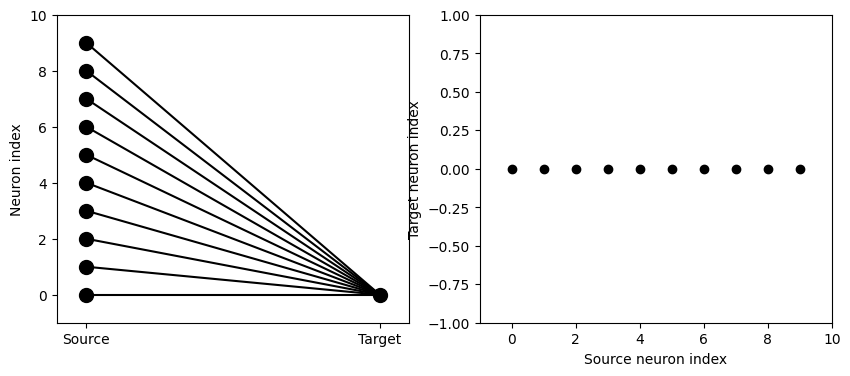

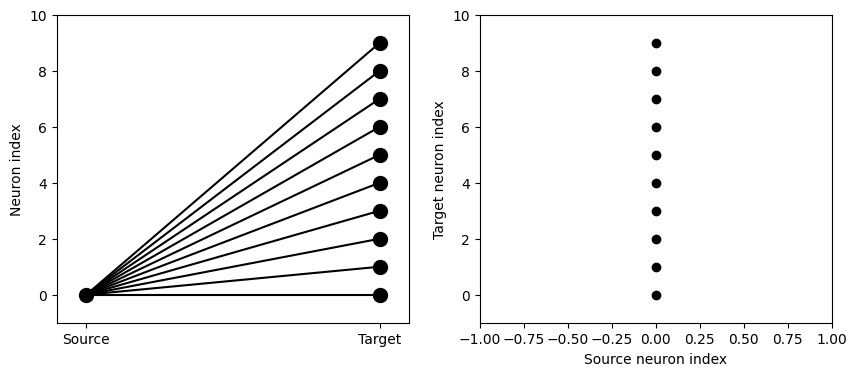

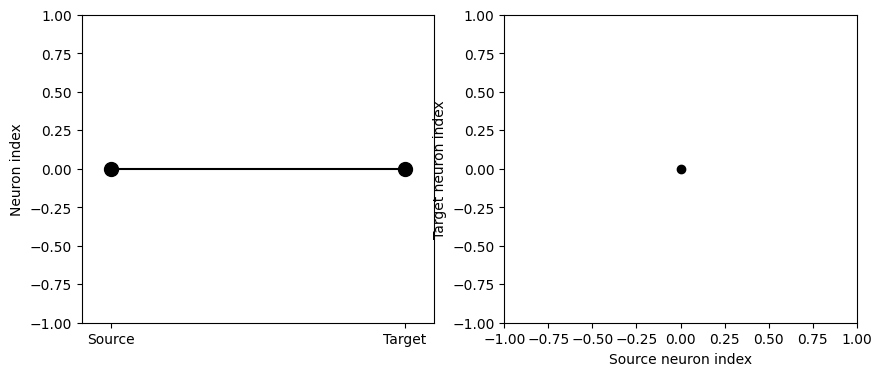

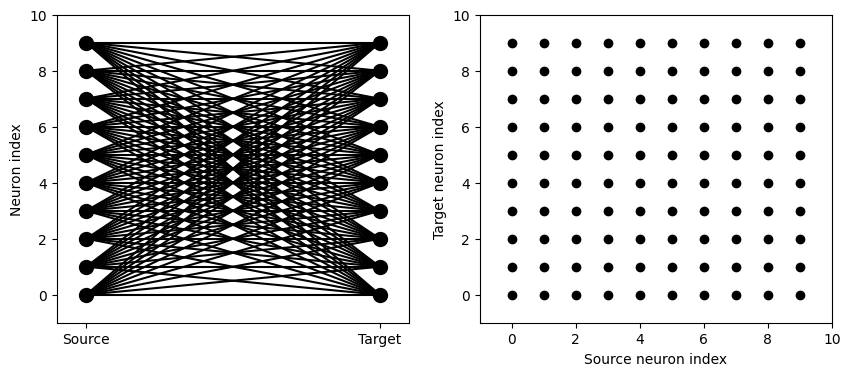

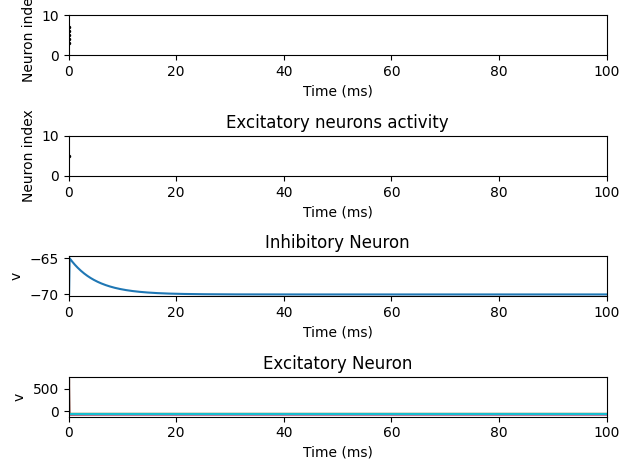

In [ ]:
from ring_attractor import RingAttractor
import numpy as np

# Creating a fake input
def gaussian(x, mu, sig):
    return np.exp(-np.power(x - mu, 2.) / (2 * np.power(sig, 2.)))

def simulate(duration, plot_states=False): #, input_weights=None, nput_gen=0, ):
        
        
        #The input generated consists of all the 10 spikes to fire in parallel at t = 0 s
        # input_weights = 100* gaussian(np.arange(0,10),4,3) #input object 
        # input_gen = SpikeGeneratorGroup(
        #     N=10, indices = np.concatenate([4*np.ones(100), 5*np.ones(100)],axis=0), times= np.concatenate([np.linspace(0,20,100), np.linspace(0,20,100)],axis=0)*ms
        # )
        
        gaussian_gen = Gaussian_Input_Generator(n=10, m=0.8, mu=180, sigma=2, noise=False)
        input_gen = gaussian_gen.to_brian2_neuron_group()
        input_weights = gaussian_gen.generate_cue()
        
        # TODO: FIx the weights
        obj_network = RingAttractor(N=10,wee = 10*mV, wei = 5*mV, wie = 10 *mV, wii = 4 *mV)
        
        connecting_input = Synapses(input_gen, obj_network.excitatory_neurons, model='W_input : volt', name="input_synapses", on_pre="V_post += W_input")
        connecting_input.connect(j="i")
        connecting_input.W_input[:] = input_weights.flatten() * volt
        print(connecting_input.W_input)
        display(connecting_input.W_input_)
        
        spike_monitor_input = SpikeMonitor(input_gen, name="spike_input")
        
        network = obj_network.net
        print(network)
        
        network.add(input_gen)
        network.add(connecting_input)
        network.add(spike_monitor_input)
        
        """
        state_monitors = StateMonitor(obj_network.excitatory_neurons, "V", record=True, name="state_excitatory")
        spike_monitors = SpikeMonitor(obj_network.excitatory_neurons, name="spike_excitatory")
        inhibitory_state_monitors = StateMonitor(obj_network.inhibit_neuron, "V", record=True, name="state_inhibitory")
        inhibitory_spike_monitors = SpikeMonitor(obj_network.inhibit_neuron, name="spike_inhibitory")
        monitors = [spike_monitor_input, state_monitors, inhibitory_state_monitors, spike_monitors, inhibitory_spike_monitors]


        network.add(monitors) #if I don`t add this nothing is really happening`
        """
        network.run(duration) #HERE ERROR

        if plot_states:
            fig, ax = plt.subplots(4,1)
            ax[0].plot(spike_monitor_input.t/ms, spike_monitor_input.i, '.k', ms=3)
            ax[0].set_xlim(0, duration/ms)
            ax[0].set_ylim(0, obj_network.N)
            ax[0].set_xlabel('Time (ms)')
            ax[0].set_ylabel('Neuron index')

            ax[1].plot(obj_network.spike_monitors.t/ms, obj_network.spike_monitors.i, '.k', ms=3)
            ax[1].set_xlim(0, duration/ms)
            ax[1].set_ylim(0, obj_network.N)
            ax[1].set_xlabel('Time (ms)')
            ax[1].set_ylabel('Neuron index')
            ax[1].set_title("Excitatory neurons activity")

            ax[2].plot(obj_network.inhibitory_state_monitors.t/ms, obj_network.inhibitory_state_monitors.V[0]/mV)
            ax[2].set_xlabel('Time (ms)')
            ax[2].set_ylabel('v')
            ax[2].set_xlim([0, duration/ms])
            ax[2].set_title('Inhibitory Neuron')

            for n in range(10):
                ax[3].plot(obj_network.state_monitors.t/ms, obj_network.state_monitors.V[n]/mV, label="%s" %n)
                
            ax[3].set_xlabel('Time (ms)')
            ax[3].set_ylabel('v')
            ax[3].set_xlim([0, duration/ms])
            ax[3].set_title('Excitatory Neuron')
            #ax[3].legend()

            plt.tight_layout()

        return obj_network.state_monitors, obj_network.spike_monitors, obj_network.inhibitory_state_monitors, obj_network.inhibitory_spike_monitors
    

#not caring anymore about the definition of the connectivity related to the 
# gaussian distribution in the inputs
#Trying running it without input (no spike, anything)
simulate(duration=100*ms, plot_states=True) #, input_gen=input_gen, input_weights=input_weights)

Ok it seems that:
- the inhibitory conditions are strong enough to regularize the connections, so that the activity doesn`t explode
- but as soon as the input is not applied anymore, the pattern is not kept in memory (the excitatory activity of the neurons instantly shuts down)
- how to keep it??? 

HYPOTESIS: increasing the excitatory connections 
- ATTENTION : if we make the weight higher than 500 mV, the activity explodes (but if I also increase wie, it gets better...but still not able to memorize anything).

The self connections of the excitatory neurons are supposed to memorize the patterns --> but if the excitatory neurons corresponding to the input keep firing, they will be inhibited by the global inhibition.

What if I change the inhibition depending on the intensity of the v???